In [49]:
import pandas as pd

In [50]:
df=pd.read_csv('KaggleV2-May-2016.csv')
# CSV dosyasını oku, 'df' kutusuna koy

In [51]:
df.head()
# ilk 5 satırı getir

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [52]:
df.isnull().sum()
# boş hücreleri toplayıp sütunla
# 0 dan farklı sayı gelirse:"O sütunda o kadar tane boş hücre var" demek

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [53]:
df.info()
"""Kaç satır veri var? 110527
Hangi sütun hangi veri tipinde? (sayı mı, yazı mı, tarih mi?)  14
Kaç tane dolu değer var?
Ne kadar bellek kullanıyor?
object:metin/yazı (örn: "F", "M", "No", "Yes")

"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


'Kaç satır veri var? 110527\nHangi sütun hangi veri tipinde? (sayı mı, yazı mı, tarih mi?)  14\nKaç tane dolu değer var?\nNe kadar bellek kullanıyor?\nobject:metin/yazı (örn: "F", "M", "No", "Yes")\n\n'

In [54]:
# şimdi tarihleri metinden zamana çevirelim
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
# Pandas'a diyoruz ki: "Bu sütundaki yazıları tarih formatına çevir!"
# Çevrilmiş halini tekrar aynı sütuna kaydediyoruz. (Eskisinin üzerine yazıyoruz)

df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [55]:
df.info()
# değişikliklerimize bakalım
# datetime64[ns] = "Artık bunlar gerçek tarih ve saat verisi!" demek.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hipertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handcap         110527 non-null  int64              
 12  SMS_received    110527 non-null  int64              
 13  No-show       

In [56]:
df['No-show'].value_counts()
# no show adlı sütunun içindeki değerleri say , yes ve no sayısını göster
# yaklaşık %80 i gelmemiş

No-show
No     88208
Yes    22319
Name: count, dtype: int64

In [57]:
df['No-show'].value_counts(normalize=True) * 100
# normalize=True -> sayıları değil oranları getir

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

In [58]:
# Yaş sütununun temel istatistiklerini görelim
df['Age'].describe()

'''count:kaç tane yaş değeri var
    mean:ortalama yaş kaç
    std:yaşlar ortalamanın etrafına ne kadar dağılmış
    min->-1 çıkmış hata var
    %25-50-75:çeyreklik değerleri (medyan dahil)
    max'''


'count:kaç tane yaş değeri var\n    mean:ortalama yaş kaç\n    std:yaşlar ortalamanın etrafına ne kadar dağılmış\n    min->-1 çıkmış hata var\n    %25-50-75:çeyreklik değerleri (medyan dahil)\n    max'

In [59]:
# kaç yerde yaş neg görelim
df[df['Age']<0]
# yaşı 0 dan küçük olanları bul ve df[] ile getir

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃO,0,0,0,0,0,0,No


In [60]:
# Yaşı 0'dan büyük veya eşit olanları tut, diğerlerini at. 
# böylece yaşı -1 olan satırı silmiş oluyoruz
# df['Age'] >= 0:"Yaş sütununda değeri 0 veya daha büyük olan satırları işaretle"
# df[ ... ]:Sadece işaretlenen (True olan) satırları getir
# df = ...:Bu filtrelenmiş halini tekrar df değişkenine kaydet (eskisinin üzerine yaz)
df = df[df['Age'] >= 0]

In [61]:
print("Kalan satır sayısı:", len(df))
print("En küçük yaş:", df['Age'].min()) #en küçük yaş sorununu çözdük 
print("En büyük yaş:", df['Age'].max())

Kalan satır sayısı: 110526
En küçük yaş: 0
En büyük yaş: 115


In [62]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [63]:
# Sütun adını düzelt.Kelime hatası var onu düzeltelim
df.rename(columns={'Handcap': 'Handicap'}, inplace=True)
# df.rename(...):Sütun isimlerini değiştir
# columns={'Handcap': 'Handicap'}:"Handcap" olanı "Handicap" yap
# inplace=True:Değişikliği doğrudan df üzerine kaydet (yeni bir tablo oluşturma)

In [64]:
df.columns
# peki biz bu handcap hatasını nasıl fark ettik
# df.head() veya df.columns komutlarını kullanarak kendimiz fark ettik (gözle okumak) ya da
# her yeni veri setine baktığımızda 7 adımlı rutini yapalım

# 1-df.shape ,df.columns :Beklediğim sütunlar var mı? İsimler mantıklı mı?

# 2-df.head() , df.sample(5) :Veri nasıl görünüyor? 
# Garip yazımlar, boşluklar, karışık formatlar var mı?

# 3-df.isnull().sum() :Hangi sütunlarda boşluk var? % kaçı eksik?

# 4-df.describe() :min/max mantıklı mı? (Yaş -1, Maaş 0, Tarih 1900 gibi)

# 5-df['col'].nunique() , .value_counts() :Kategoriler tutarlı mı? 
# ("Evet", "evet", "E ", "Yes" gibi karışıklık var mı?)

# 6-df.info() :Tarihler object mi? Sayılar float mı? Boolean'lar int mi?
# 7-mantık yürütme :120 yaşında hasta olur mu , sms 2025 yılında mı gönderilmiş

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No-show'],
      dtype='object')

In [65]:
# Bekleme süresini gün cinsinden hesapla
df['wait_days']=(df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [66]:
df['wait_days'].describe()

count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: wait_days, dtype: float64

In [67]:
print("📅 Tarih sütunlarının veri tipi:")
print(df[['ScheduledDay', 'AppointmentDay']].dtypes)

print("\n⏳ Bekleme süresi (wait_days) istatistikleri:")
print(df['wait_days'].describe())

# min          -7.000000   ← 🚨 NEGATİF BEKLEME SÜRESİ?!Randevu, planlamadan ÖNCE olmuş olamaz!
# 25%          -1.000000   ← Çeyreklik değer de negatif!

#  Yani: Verimizde, "randevu tarihi"nin "planlama tarihi"nden önce olduğu kayıtlar var.
# Bu ya bir veri giriş hatası, ya da sistemde özel bir durum (acil randevu, tarih düzeltme vb.).

📅 Tarih sütunlarının veri tipi:
ScheduledDay      datetime64[ns, UTC]
AppointmentDay    datetime64[ns, UTC]
dtype: object

⏳ Bekleme süresi (wait_days) istatistikleri:
count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: wait_days, dtype: float64


In [68]:
# 🔹 Seçenek A: Negatif olan satırları tamamen silmek (En güvenli)

# Sadece bekleme süresi 0 veya pozitif olanları tut
df = df[df['wait_days'] >= 0]

# bunu yapalım

In [69]:
# 🔹 Seçenek B: Negatif değerleri 0'a eşitlemek (Daha yumuşak)

# Negatifleri 0 yap, diğerlerine dokunma
df['wait_days'] = df['wait_days'].clip(lower=0)

burda bilgisayarı kapatmıştım . şöyle hızlısından kodları çalıştıralım


In [70]:
import pandas as pd

# 1. Veriyi yükle
df = pd.read_csv('KaggleV2-May-2016.csv')

# 2. Tarihleri gerçek formata çevir
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# 3. Negatif yaşları temizle
df = df[df['Age'] >= 0]

# 4. Bekleme süresini hesapla
df['wait_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# 5. Negatif bekleme sürelerini temizle
df = df[df['wait_days'] >= 0]

# 6. Yazım hatasını düzelt
df.rename(columns={'Handcap': 'Handicap'}, inplace=True)

print("✅ Ortam hazır! Tüm temizlikler uygulandı.")
print(f"Kalan satır sayısı: {len(df)}")
print(f"En küçük yaş: {df['Age'].min()} | En küçük bekleme: {df['wait_days'].min()}")

✅ Ortam hazır! Tüm temizlikler uygulandı.
Kalan satır sayısı: 71959
En küçük yaş: 0 | En küçük bekleme: 0


In [71]:
print("📊 Son Kontroller:")
print(f"En küçük yaş: {df['Age'].min()}")
print(f"En küçük bekleme süresi: {df['wait_days'].min()}")
print(f"\nNo-show dağılımı:\n{df['No-show'].value_counts()}") #Tablomuzdaki No-show sütununu seçer,"Bu sütunda her değerden kaç tane var?"

📊 Son Kontroller:
En küçük yaş: 0
En küçük bekleme süresi: 0

No-show dağılımı:
No-show
No     51437
Yes    20522
Name: count, dtype: int64


In [72]:
df['No-show'].value_counts(normalize=True) * 100
# No-show
# No     71.480982    kişi gelmiş
# Yes    28.519018    kişi gelmemiş

No-show
No     71.480982
Yes    28.519018
Name: proportion, dtype: float64

In [73]:
# Randevu gününün haftanın hangi günü olduğunu bul
# 0=Pazartesi, 1=Salı, ..., 5=Cumartesi, 6=Pazar
df['day_of_week'] = df['AppointmentDay'].dt.dayofweek

In [74]:
# Gün isimlerini Türkçe olarak ekleyelim (opsiyonel ama güzel)
gun_isimleri = {
    0: 'Pazartesi', 
    1: 'Salı', 
    2: 'Çarşamba', 
    3: 'Perşembe', 
    4: 'Cuma', 
    5: 'Cumartesi', 
    6: 'Pazar'
}

In [75]:

df['gun_adi'] = df['day_of_week'].map(gun_isimleri)

print("✅ Gün bilgileri eklendi!")
print("\nHaftanın günlerine göre randevu dağılımı:")
print(df['gun_adi'].value_counts())


✅ Gün bilgileri eklendi!

Haftanın günlerine göre randevu dağılımı:
gun_adi
Çarşamba     17044
Salı         16462
Pazartesi    14581
Cuma         12516
Perşembe     11325
Cumartesi       31
Name: count, dtype: int64


In [76]:
# bekeleme süresini anlamlı gruplara bölelim 
# pd.cut(...):Sayısal bir sütunu (wait_days), verdiğimiz aralıklara (bins) göre kategorik gruplara böler.
df['wait_group']=pd.cut(df['wait_days'],
bins=[0,1,7,30,365],  #aralıklar
labels=['aynı gün','1-7gün','7-30gün','30+gün'])    #aralıklara verdiğimiz isimler

# her grup için "gelme/gelmeme oranlarını hesaplayalım
analysis =df.groupby('wait_group')['No-show'].value_counts(normalize=True).unstack()

# .groupby('wait_group'):Veriyi bu yeni gruplara göre ayırır.
''' 
['No-show'].value_counts(normalize=True):Her grupta No ve Yes kaç kez geçmiş, oran (%) olarak hesaplar.
.unstack():Çıktıyı yan yana tablo formatına çevirir (gruplar satır, No/Yes sütun olur).
'''
# sadece gelmemeye "yes" sütununu çekip sıralayalım  ,  analysis['Yes']:Sadece "Gelmemeyi" (Yes) temsil eden sütunu çeker.
no_show_rates = analysis['Yes'].sort_index()

print("bekleme süresine göre randevıya gelmeme oranları:")
print(no_show_rates)

bekleme süresine göre randevıya gelmeme oranları:
wait_group
aynı gün    0.238216
1-7gün      0.253643
7-30gün     0.319981
30+gün      0.330208
Name: Yes, dtype: float64


C:\Users\semra\AppData\Local\Temp\ipykernel_31488\2819421946.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis =df.groupby('wait_group')['No-show'].value_counts(normalize=True).unstack()


yani bekleme süresi arttıkça gelmemeye eğilim artıyormuş
 Uzun vadeli randevulara otomatik SMS hatırlatma eklenebilir
 30+ gün bekleyen hastalara 1 hafta kala teyit aranabilir

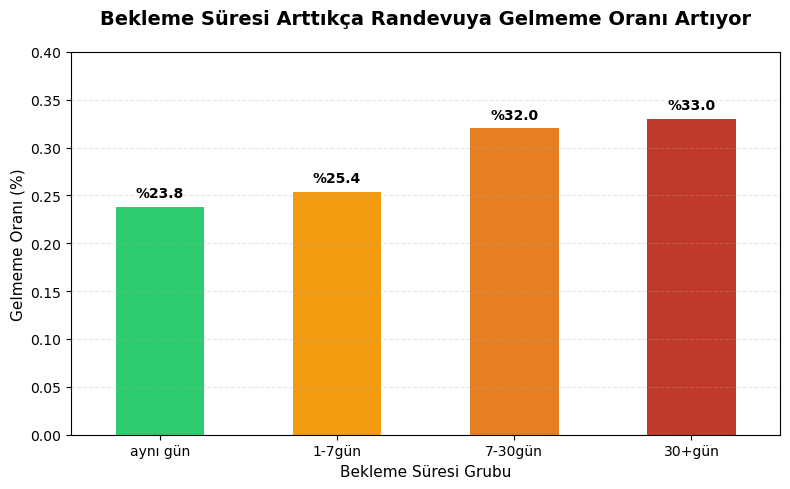

In [77]:
import matplotlib.pyplot as plt

# Grafik boyutunu ayarla
plt.figure(figsize=(8, 5))

# Çubuk grafik çiz
no_show_rates.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e67e22', '#c0392b'])

# Başlık ve etiketler
plt.title('Bekleme Süresi Arttıkça Randevuya Gelmeme Oranı Artıyor', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Bekleme Süresi Grubu', fontsize=11)
plt.ylabel('Gelmeme Oranı (%)', fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, 0.4)  # Y eksenini 0-40% arasına sabitler, karşılaştırmayı kolaylaştırır

# Yüzde etiketlerini çubukların üstüne yaz
for i, v in enumerate(no_show_rates):
    plt.text(i, v + 0.01, f'%{v*100:.1f}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--') #Yatay ızgara ekler, değer okumayı kolaylaştırır
plt.tight_layout()   #Etiketlerin kesilmesini engeller, düzeni optimize eder
plt.show()

Soru: "Neden çubuk grafik (bar chart) seçtin? Başka hangi grafik türlerini düşündün?"

 Cevap: "Kategorik bir değişken (wait_group) ile oran (No-show %) karşılaştırıyordum. Çubuk grafik, gruplar arası farkları en net gösteren türdür. Pasta grafik oranları gösterir ama grupları karşılaştırmak zordur. Çizgi grafik zaman serisi içindir, burada uygun değil. Bu nedenle çubuk grafik en iyi tercihti."


In [78]:
df_final = df[columns_to_keep].copy()


# CSV olarak kaydet
df_final.to_csv('cleaned_medical_appointments.csv', index=False, encoding='utf-8-sig')

# index=False:Satır numaralarını (0,1,2...) dosyaya yazmaz, temiz çıktı sağlar
# encoding='utf-8-sig':Türkçe karakterlerin (Ş,ğ,ü) Excel'de düzgün açılmasını sağlar
print("✅ Temiz veri başarıyla kaydedildi!")
print(f"📁 Dosya adı: cleaned_medical_appointments.csv")
print(f"📊 Boyut: {df_final.shape[0]} satır × {df_final.shape[1]} sütun")

✅ Temiz veri başarıyla kaydedildi!
📁 Dosya adı: cleaned_medical_appointments.csv
📊 Boyut: 71959 satır × 14 sütun


In [79]:
#  Soru: "Neden tüm sütunları kaydetmedin, bazılarını çıkardın?"
# ✅ Cevap: "AppointmentID gibi teknik kimlikler veya ScheduledDay gibi ham tarihler, analiz için gerekli ama raporlama için kalabalık yapabilir. Sadece anlamlı ve yorumlanabilir sütunları tutarak, veriyi 'kullanıcı dostu' hale getirdim. Bu, veri mühendisliğinde 'minimal viable dataset' prensibidir."
# Gereksiz sütunları çıkar (opsiyonel, raporu sadeleştirir)
columns_to_keep = [
    'PatientId', 'Age', 'Gender', 'Neighbourhood',
    'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handicap',
    'SMS_received', 'No-show', 'wait_days', 'wait_group', 'day_of_week'
]
df_final = df[columns_to_keep].copy()

# CSV olarak kaydet
df_final.to_csv('cleaned_medical_appointments.csv', index=False, encoding='utf-8-sig')

print("✅ Temiz veri başarıyla kaydedildi!")
print(f"📁 Dosya adı: cleaned_medical_appointments.csv")
print(f"📊 Boyut: {df_final.shape[0]} satır × {df_final.shape[1]} sütun")

✅ Temiz veri başarıyla kaydedildi!
📁 Dosya adı: cleaned_medical_appointments.csv
📊 Boyut: 71959 satır × 14 sütun


bu kısım bu kadardı . sms dosyasında başka bir analiz var.